# Packages & Global Info

In [18]:
# Packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
# Aggregation levels
levels = {'1 min': 1/60, '10 min': 1/6, '30 min': 0.5, '1 h': 1,
              '2 h': 2, '3 h': 3, '4 h': 4, '6 h': 6, '8 h': 8, '12 h': 12, '24 h': 24}

agg_levels = np.array([h for _, h in levels.items()])

# Baseline

In [20]:
# baseline data
baseline_df = pd.read_csv('/home/ma/t/tr725/MSc-Project/03_code/composite_stability/composite_stability.csv', index_col=0)

baseline_results = {}
for col in baseline_df.columns:
    baseline_results[col] = {
        tuple(int(x) for x in idx.split("-")): val
        for idx, val in baseline_df[col].items()
    }

# Number of Authentications

In [21]:
# n_auth data
n_auth_df = pd.read_csv("/home/ma/t/tr725/MSc-Project/03_code/ablation_analysis/drop_nauth/drop_nauth_combined.csv", index_col=0)

n_auth_results = {}
for col in n_auth_df.columns:
    n_auth_results[col] = {
        tuple(int(x) for x in idx.split("-")): val
        for idx, val in n_auth_df[col].items()
    }

# Failure Ratio

In [22]:
# failrate data
failrate_df = pd.read_csv("/home/ma/t/tr725/MSc-Project/03_code/ablation_analysis/drop_failrate/drop_failrate_combined.csv", index_col=0)

failrate_results = {}
for col in failrate_df.columns:
    failrate_results[col] = {
        tuple(int(x) for x in idx.split("-")): val
        for idx, val in failrate_df[col].items()
    }

# Number of Distinct Source Computers

In [23]:
# n_src_comps data
n_src_comps_df = pd.read_csv("/home/ma/t/tr725/MSc-Project/03_code/ablation_analysis/drop_src_comps/drop_src_comps_combined.csv", index_col=0)

n_src_comps_results = {}
for col in n_src_comps_df.columns:
    n_src_comps_results[col] = {
        tuple(int(x) for x in idx.split("-")): val
        for idx, val in n_src_comps_df[col].items()
    }

# Number of Distinct Destination Computers

In [24]:
# n_dest_comps data
n_dest_comps_df = pd.read_csv("/home/ma/t/tr725/MSc-Project/03_code/ablation_analysis/drop_dest_comps/drop_dest_comps_combined.csv", index_col=0)

n_dest_comps_results = {}
for col in n_dest_comps_df.columns:
    n_dest_comps_results[col] = {
        tuple(int(x) for x in idx.split("-")): val
        for idx, val in n_dest_comps_df[col].items()
    }

# Time

In [25]:
# time data
time_df = pd.read_csv("/home/ma/t/tr725/MSc-Project/03_code/ablation_analysis/drop_time/drop_time_combined.csv", index_col=0)

time_results = {}
for col in time_df.columns:
    time_results[col] = {
        tuple(int(x) for x in idx.split("-")): val
        for idx, val in time_df[col].items()
    }

# Ablation Analysis 

In [28]:
# Dropped features results
dropped_features = {
    'Authentication Events': n_auth_results,
    'Source Computers': n_src_comps_results,
    'Destination Computers': n_dest_comps_results,
    'Failure Rate': failrate_results,    
    'Mean Time of Day': time_results,
}

# Colour scheme
colors = {
    'Authentication Events': '#4C72B0',       # blue
    'Source Computers': '#55A868',  # green
    'Destination Computers': '#C44E52', # red
    'Failure Rate': '#DD8452',    # orange
    'Mean Time of Day': '#8172B2',         # purple
}


# Plot of Medians

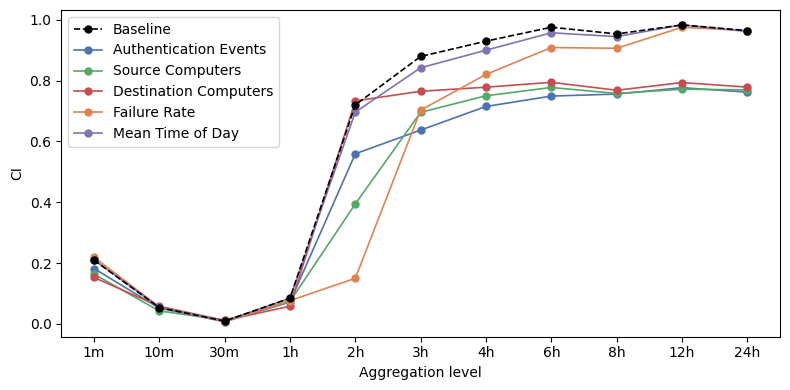

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))

# Baseline 
baseline_vals = [np.array(list(baseline_results[col].values())) for col in levels]
baseline_medians = np.array([np.median(v) for v in baseline_vals])
ax.plot(np.arange(len(levels)), baseline_medians, marker='o', ms=5, lw=1.2, ls='--',
         color='black', zorder=2, label='Baseline')

# Dropped features
for name, results in dropped_features.items():
    vals = [np.array(list(results[col].values())) for col in levels]
    medians = np.array([np.median(v) for v in vals])
    ax.plot(np.arange(len(levels)), medians, marker='o', ms=5, lw=1.2, zorder=1,
             label=name, color=colors[name])

# Format x-axis with equal spacing
labels = ['1m', '10m', '30m', '1h', '2h', '3h', '4h', '6h', '8h', '12h', '24h']
ax.set_xticks(np.arange(len(levels)))
ax.set_xticklabels(labels)

ax.set_xlabel('Aggregation level')
ax.set_ylabel('CI')
ax.legend(loc='upper left')
plt.tight_layout()

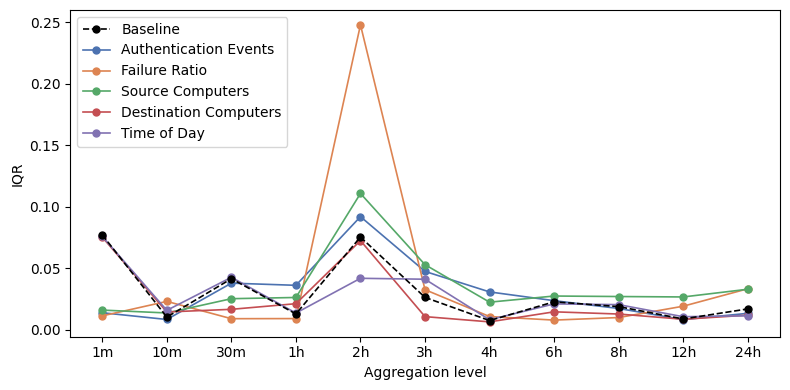

In [34]:
fig, ax = plt.subplots(figsize=(8, 4))

# Interquartile range function
def iqr(arr):
    q1, q3 = np.percentile(arr, [25, 75])
    return q3 - q1

# Baseline
baseline_vals = [np.array(list(baseline_results[col].values())) for col in levels]
baseline_iqr = np.array([iqr(v) for v in baseline_vals])
ax.plot(np.arange(len(levels)), baseline_iqr, marker='o', ms=5, lw=1.2, ls='--',
         color='black', zorder=2, label='Baseline')

# Dropped features
for name, results in dropped_features.items():
    vals = [np.array(list(results[col].values())) for col in levels]
    iqrs = np.array([iqr(v) for v in vals])
    ax.plot(np.arange(len(levels)), iqrs, marker='o', ms=5, lw=1.2, zorder=1,
             label=name, color=colors[name])

ax.set_xticks(np.arange(len(levels)))
ax.set_xticklabels(['1m', '10m', '30m', '1h', '2h', '3h', '4h', '6h', '8h', '12h', '24h'])
ax.minorticks_off()
ax.set_xlabel('Aggregation level')
ax.set_ylabel('IQR')
ax.legend(loc='upper left')
plt.tight_layout()

# Deeper Analysis 

## Median Trend

In [13]:
# The largest difference in stability between baseline and dropped time of day dropped 
diffs = {col: np.median(list(baseline_results[col].values())) - np.median(list(time_results[col].values())) for col in levels}
max_level = max(diffs, key=lambda k: abs(diffs[k]))
print(max_level, diffs[max_level])

3 h 0.037150063416420354


In [14]:
# Maximum of baseline
baseline_medians = {col: np.median(list(baseline_results[col].values())) for col in levels}
max_level = max(baseline_medians, key=baseline_medians.get)
print(max_level, baseline_medians[max_level])

12 h 0.9835194665677114


In [15]:
# Maximum of destination computers (dropped)
destination_medians = {col: np.median(list(n_dest_comps_results[col].values())) for col in levels}
max_level = max(destination_medians, key=destination_medians.get)
print(max_level, destination_medians[max_level])

6 h 0.794697969132934


In [16]:
# Maximum of source computers (dropped)
source_medians = {col: np.median(list(n_src_comps_results[col].values())) for col in levels}
max_level = max(source_medians, key=source_medians.get)
print(max_level, source_medians[max_level])

6 h 0.7777221399930261


In [17]:
# Maximum of auth events (dropped)
auth_medians = {col: np.median(list(n_auth_results[col].values())) for col in levels}
max_level = max(auth_medians, key=auth_medians.get)
print(max_level, auth_medians[max_level])

12 h 0.7769535738718392


In [18]:
# Difference in transtion from 1 to 2 hours for baseline and failrate 
baseline_1h = np.median(list(baseline_results['1 h'].values()))
baseline_2h = np.median(list(baseline_results['2 h'].values()))
failrate_1h = np.median(list(failrate_results['1 h'].values()))
failrate_2h = np.median(list(failrate_results['2 h'].values()))
baseline_diff = baseline_2h - baseline_1h
failrate_diff = failrate_2h - failrate_1h

print(f"Baseline difference (1h to 2h): {baseline_diff}")
print(f"Failrate difference (1h to 2h): {failrate_diff}")

print(f"Ratio (Baseline/Failrate): {baseline_diff/failrate_diff}")

Baseline difference (1h to 2h): 0.6360377449180358
Failrate difference (1h to 2h): 0.07333314675639391
Ratio (Baseline/Failrate): 8.673264042942215


In [19]:
# Maximum of fail rate (dropped)
failrate_medians = {col: np.median(list(failrate_results[col].values())) for col in levels}
max_level = max(failrate_medians, key=failrate_medians.get)
print(max_level, failrate_medians[max_level])

12 h 0.9757306110729292


In [20]:
0.9835194665677114 - 0.9757306110729292

0.007788855494782143

## IQR trend

In [21]:
# 2 hour aggregation level values
col = '2 h'

baseline_iqr_2h = iqr(np.array(list(baseline_results[col].values())))
print("Baseline:", baseline_iqr_2h)

for name, results in dropped_features.items():
    val = iqr(np.array(list(results[col].values())))
    print(f"{name}: {val}")

Baseline: 0.07536318260434305
Authentication Events: 0.0919239537832468
Failure Ratio: 0.24771422712030206
Source Computers: 0.11075807650887076
Destination Computers: 0.07246688230174847
Time of Day: 0.04185122329298596


In [37]:
0.24771422712030206 - 0.07536318260434305

0.172351044515959

In [24]:
# %%
all_iqrs = []

for col in levels:
    all_iqrs.append(iqr(list(baseline_results[col].values())))
    for name, results in dropped_features.items():
        all_iqrs.append(iqr(list(results[col].values())))

all_iqrs = np.array(all_iqrs)
pct_below = (all_iqrs < 0.05).mean() * 100
print(f"{pct_below:.2f}% of IQR values are below 0.05")
print(f"({(all_iqrs < 0.05).sum()} out of {len(all_iqrs)})")

86.36% of IQR values are below 0.05
(57 out of 66)


In [26]:
# %%
baseline_iqrs = {col: iqr(list(baseline_results[col].values())) for col in levels}

deviations = {}  # name -> {level: abs deviation}
for name, results in dropped_features.items():
    deviations[name] = {
        col: abs(iqr(list(results[col].values())) - baseline_iqrs[col])
        for col in levels
    }

# %%
print(f"{'Feature':<25}{'Median (all levels)':<20}{'At 2h':<10}{'Ratio':<10}")
for name, dev in deviations.items():
    all_levels_median = np.median(list(dev.values()))
    at_2h = dev['2 h']
    ratio = at_2h / all_levels_median if all_levels_median > 0 else np.nan
    print(f"{name:<25}{all_levels_median:<20.4f}{at_2h:<10.4f}{ratio:<10.1f}")

# %%
# Pooled across all conditions
all_levels_vals = [v for dev in deviations.values() for v in dev.values()]
all_at_2h = [dev['2 h'] for dev in deviations.values()]

pooled_median_all = np.median(all_levels_vals)
pooled_median_at_2h = np.median(all_at_2h)
pooled_ratio = pooled_median_at_2h / pooled_median_all

print(f"\nPooled median deviation (all levels): {pooled_median_all:.4f}")
print(f"Pooled median deviation at 2h: {pooled_median_at_2h:.4f}")
print(f"Ratio: {pooled_ratio:.1f}x")

Feature                  Median (all levels) At 2h     Ratio     
Authentication Events    0.0036              0.0166    4.6       
Failure Ratio            0.0128              0.1724    13.5      
Source Computers         0.0160              0.0354    2.2       
Destination Computers    0.0051              0.0029    0.6       
Time of Day              0.0017              0.0335    19.8      

Pooled median deviation (all levels): 0.0081
Pooled median deviation at 2h: 0.0335
Ratio: 4.1x


In [28]:
baseline_iqrs = {col: iqr(list(baseline_results[col].values())) for col in levels}

deviations = {}  # name -> {level: abs deviation}
for name, results in dropped_features.items():
    deviations[name] = {
        col: abs(iqr(list(results[col].values())) - baseline_iqrs[col])
        for col in levels
    }

# %%
print(f"{'Feature':<25}{'Mean (all levels)':<20}{'At 2h':<10}{'Ratio':<10}")
for name, dev in deviations.items():
    all_levels_mean = np.mean(list(dev.values()))
    at_2h = dev['2 h']
    ratio = at_2h / all_levels_mean if all_levels_mean > 0 else np.nan
    print(f"{name:<25}{all_levels_mean:<20.4f}{at_2h:<10.4f}{ratio:<10.1f}")

# %%
# Pooled across all conditions
all_levels_vals = [v for dev in deviations.values() for v in dev.values()]
all_at_2h = [dev['2 h'] for dev in deviations.values()]

pooled_mean_all = np.mean(all_levels_vals)
pooled_mean_at_2h = np.mean(all_at_2h)
pooled_ratio = pooled_mean_at_2h / pooled_mean_all

print(f"\nPooled mean deviation (all levels): {pooled_mean_all:.4f}")
print(f"Pooled mean deviation at 2h: {pooled_mean_at_2h:.4f}")
print(f"Ratio: {pooled_ratio:.1f}x")

Feature                  Mean (all levels)   At 2h     Ratio     
Authentication Events    0.0145              0.0166    1.1       
Failure Ratio            0.0316              0.1724    5.5       
Source Computers         0.0198              0.0354    1.8       
Destination Computers    0.0071              0.0029    0.4       
Time of Day              0.0062              0.0335    5.4       

Pooled mean deviation (all levels): 0.0158
Pooled mean deviation at 2h: 0.0521
Ratio: 3.3x


In [29]:
# %%
baseline_iqrs = {col: iqr(list(baseline_results[col].values())) for col in levels}

deviations = {}  # name -> {level: signed deviation}
for name, results in dropped_features.items():
    deviations[name] = {
        col: iqr(list(results[col].values())) - baseline_iqrs[col]
        for col in levels
    }

# %%
print(f"{'Feature':<25}{'Mean (all levels)':<20}{'At 2h':<10}")
for name, dev in deviations.items():
    all_levels_mean = np.mean(list(dev.values()))
    at_2h = dev['2 h']
    print(f"{name:<25}{all_levels_mean:<20.4f}{at_2h:<10.4f}")

# %%
# Pooled across all conditions
all_levels_vals = [v for dev in deviations.values() for v in dev.values()]
all_at_2h = [dev['2 h'] for dev in deviations.values()]

pooled_mean_all = np.mean(all_levels_vals)
pooled_mean_at_2h = np.mean(all_at_2h)

print(f"\nPooled mean signed deviation (all levels): {pooled_mean_all:.4f}")
print(f"Pooled mean signed deviation at 2h: {pooled_mean_at_2h:.4f}")

Feature                  Mean (all levels)   At 2h     
Authentication Events    0.0010              0.0166    
Failure Ratio            0.0087              0.1724    
Source Computers         0.0057              0.0354    
Destination Computers    -0.0048             -0.0029   
Time of Day              -0.0014             -0.0335   

Pooled mean signed deviation (all levels): 0.0018
Pooled mean signed deviation at 2h: 0.0376


In [31]:
# %%
baseline_iqrs = {col: iqr(list(baseline_results[col].values())) for col in levels}

rows = []
for name, results in dropped_features.items():
    devs = {col: iqr(list(results[col].values())) - baseline_iqrs[col] for col in levels}
    n_higher = sum(1 for v in devs.values() if v > 0)
    avg_dev = np.mean(list(devs.values()))
    rows.append({'Feature': name, 'Higher than baseline (out of 11)': n_higher, 'Mean deviation': avg_dev})

table = pd.DataFrame(rows)
table.sort_values(by='Higher than baseline (out of 11)', ascending=False, inplace=True)

,Feature,Higher than baseline (out of 11),Mean deviation
2,Source Computers,9,0.005736
4,Time of Day,7,-0.001442
1,Failure Ratio,6,0.008692
0,Authentication Events,5,0.000972
3,Destination Computers,2,-0.004844
